# Import Libraries

In [1]:
import os
import math
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pwlf
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
neuron_num_FC_layer_0 = 256
neuron_num_FC_layer_1 = 256
neuron_num_FC_layer_2 = 256
neuron_num_OUT_layer  = 10

#### Hyperparameters setting here.

In [3]:
epochs = 100
batch_sizes = [64]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.001, 0.0005]
lr_min_pool = [0.00001, 0.000001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
GPU_device = "cuda:0"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [5]:
save_path     = "SFC_float"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/FashionMNIST/Baseline/dataset 

Training Data Output Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/FashionMNIST/Baseline/train/SFC_float 

Training Report Output Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/FashionMNIST/Baseline/report


#### Following are the code to complete the network definition

In [6]:
input_length  = 28*28

hidden_0      = neuron_num_FC_layer_0
hidden_1      = neuron_num_FC_layer_1
hidden_2      = neuron_num_FC_layer_2

output_length = neuron_num_OUT_layer

In [7]:
class MLP(nn.Module):
    def __init__(self, dropout=0.5):
        super(MLP, self).__init__()
        
        self.fc0   = nn.Linear(input_length, hidden_0)
        self.bn0   = nn.BatchNorm1d(hidden_0)
        self.relu0 = nn.ReLU()
        self.drop0 = nn.Dropout(dropout)
        
        self.fc1   = nn.Linear(hidden_0, hidden_1)
        self.bn1   = nn.BatchNorm1d(hidden_1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)
        
        self.fc2   = nn.Linear(hidden_1, hidden_2)
        self.bn2   = nn.BatchNorm1d(hidden_2)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)
        
        self.out   = nn.Linear(hidden_2, output_length)

    def forward(self, x):
        
        out = x.reshape(x.shape[0], -1)
        out = self.drop0(self.relu0(self.bn0(self.fc0(out))))
        out = self.drop1(self.relu1(self.bn1(self.fc1(out))))
        out = self.drop2(self.relu2(self.bn2(self.fc2(out))))
        out = self.out(out)
        
        return out

# Random Seed Utility

In [8]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [9]:
test_batch_size = 4096

In [10]:
def get_dataloaders(batch_size):    
    train_dataset = datasets.FashionMNIST(  dataset_root, 
                                     train=True, 
                                     download=True,
                                     transform=transforms.Compose
                                     ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                     ])
                                  )
    test_dataset  = datasets.FashionMNIST( dataset_root, 
                                    train=False, 
                                    download=True,
                                    transform=transforms.Compose
                                    ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                    ])
                                  )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

# Evaluation Pipeline

In [11]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [12]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [13]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = MLP(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        train_loss /= total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        #print(log_line)
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f |" % (lr, train_acc, val_acc))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc

# Hyperparameter Searching for Network Training and Testing

In [14]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout = results[0]
    print(f"🏆 Best Config: {best_config} Accuracy: {best_acc:.4f}")
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")

🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.0


🔄 Resuming from epoch 100


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

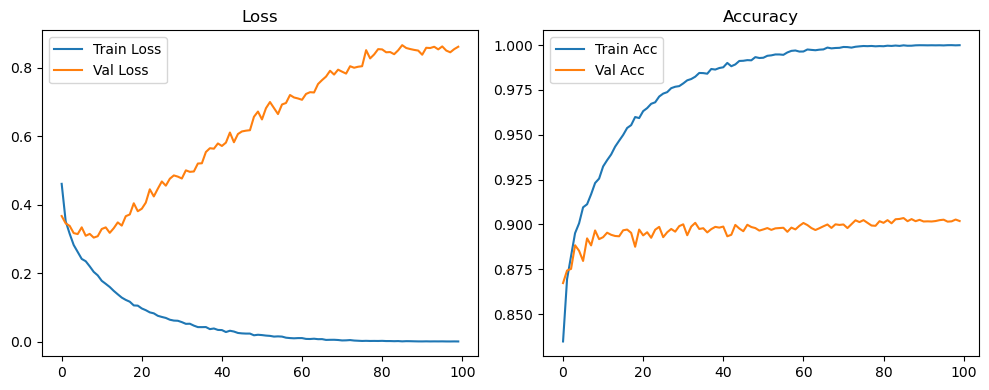

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.05s/it]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.41it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.08it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.74it/s]

Original Model Final Test Loss: 0.9024 Accuracy: 0.8987


🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.05
🔄 Resuming from epoch 100


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

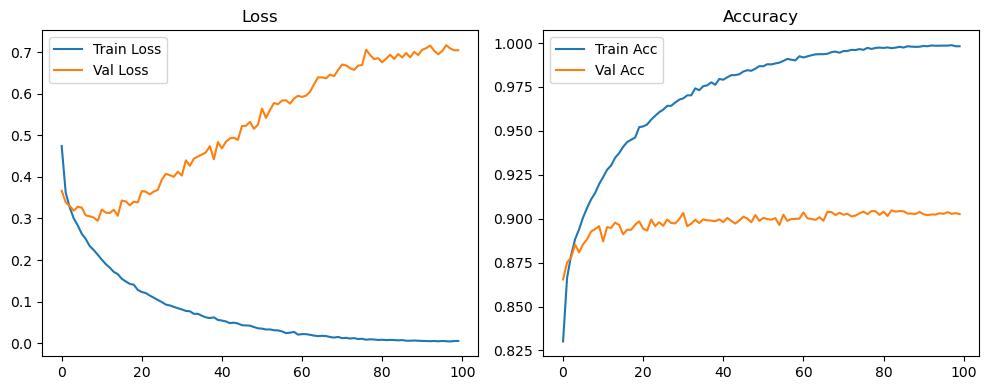

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.18it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.17it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.92it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.67it/s]

Original Model Final Test Loss: 0.7403 Accuracy: 0.9047


🚀 Running: batch64_lr_max_0.001_min_1e-05_dp0.1
🔄 Resuming from epoch 100


Training: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

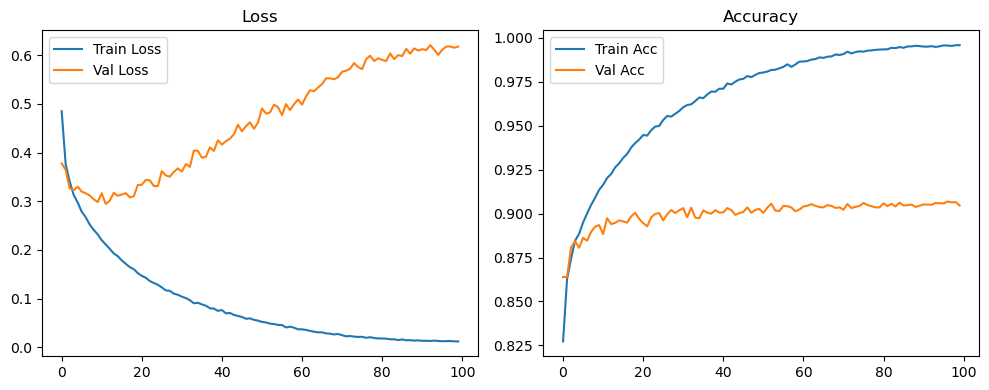

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.17it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.16it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.89it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.65it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.9038 |:  88%|████████▊ | 7/8 [00:17<00:02,  2.31s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9031 |:  88%|████████▊ | 7/8 [00:19<00:02,  2.31s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9031 |:  88%|████████▊ | 7/8 [00:19<00:02,  2.31s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9031 |: 100%|██████████| 8/8 [00:19<00:00,  2.24s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9031 |: 100%|██████████| 8/8 [00:19<00:00,  2.45s/it]

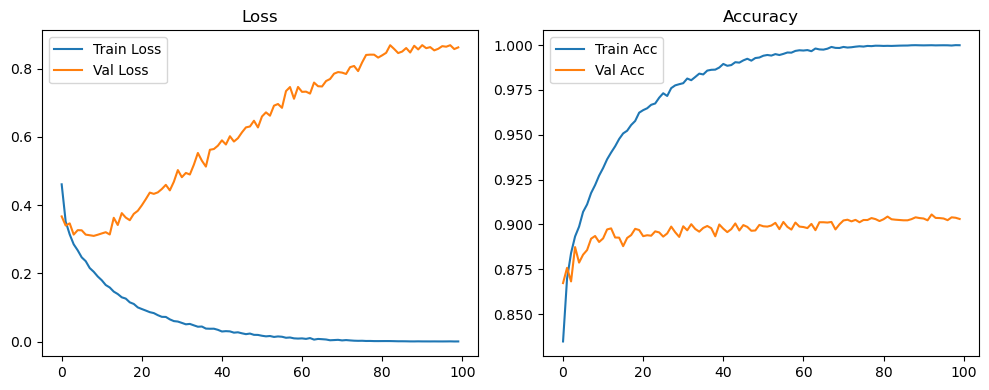

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.08it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.10it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.83it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.58it/s]

...

| LR: 0.000002 | Train Acc: 0.9985 | Val Acc: 0.9038 |:  99%|█████████▉| 99/100 [04:08<00:02,  2.47s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9038 |:  99%|█████████▉| 99/100 [04:10<00:02,  2.47s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9038 |:  99%|█████████▉| 99/100 [04:10<00:02,  2.47s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9038 |: 100%|██████████| 100/100 [04:10<00:00,  2.43s/it]

| LR: 0.000001 | Train Acc: 0.9984 | Val Acc: 0.9038 |: 100%|██████████| 100/100 [04:10<00:00,  2.50s/it]

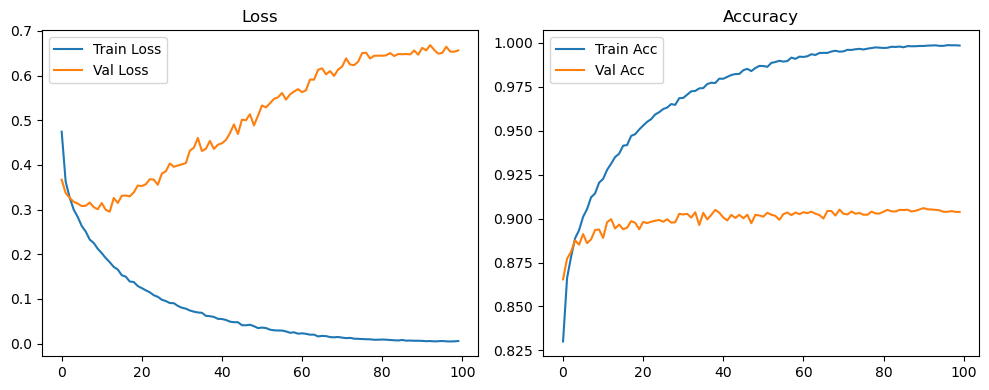

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.04it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.09it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.81it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.56it/s]

...

| LR: 0.000002 | Train Acc: 0.9956 | Val Acc: 0.9073 |:  99%|█████████▉| 99/100 [04:03<00:02,  2.47s/it]

| LR: 0.000001 | Train Acc: 0.9951 | Val Acc: 0.9066 |:  99%|█████████▉| 99/100 [04:05<00:02,  2.47s/it]

| LR: 0.000001 | Train Acc: 0.9951 | Val Acc: 0.9066 |:  99%|█████████▉| 99/100 [04:05<00:02,  2.47s/it]

| LR: 0.000001 | Train Acc: 0.9951 | Val Acc: 0.9066 |: 100%|██████████| 100/100 [04:05<00:00,  2.52s/it]

| LR: 0.000001 | Train Acc: 0.9951 | Val Acc: 0.9066 |: 100%|██████████| 100/100 [04:05<00:00,  2.46s/it]

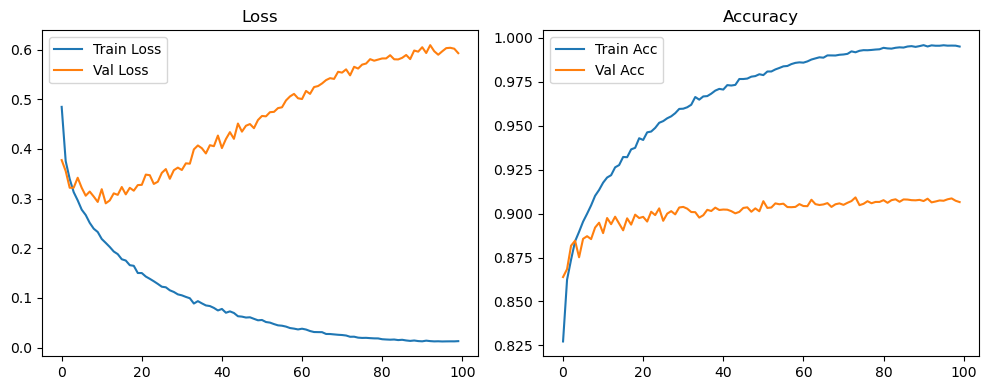

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.96it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.03it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.73it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.48it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.8996 |:  99%|█████████▉| 99/100 [04:00<00:02,  2.36s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8988 |:  99%|█████████▉| 99/100 [04:03<00:02,  2.36s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8988 |:  99%|█████████▉| 99/100 [04:03<00:02,  2.36s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8988 |: 100%|██████████| 100/100 [04:03<00:00,  2.38s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.8988 |: 100%|██████████| 100/100 [04:03<00:00,  2.43s/it]

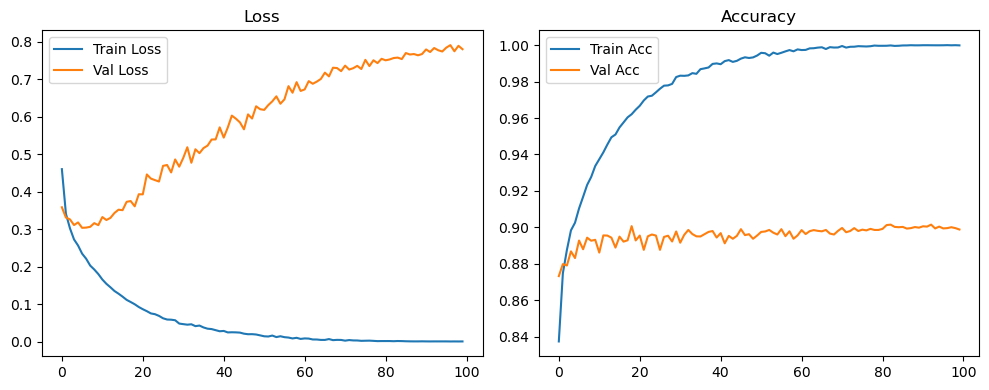

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.03it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.06it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.78it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.53it/s]

...

| LR: 0.000010 | Train Acc: 0.9985 | Val Acc: 0.9050 |:  99%|█████████▉| 99/100 [04:05<00:02,  2.43s/it]

| LR: 0.000010 | Train Acc: 0.9985 | Val Acc: 0.9044 |:  99%|█████████▉| 99/100 [04:07<00:02,  2.43s/it]

| LR: 0.000010 | Train Acc: 0.9985 | Val Acc: 0.9044 |:  99%|█████████▉| 99/100 [04:07<00:02,  2.43s/it]

| LR: 0.000010 | Train Acc: 0.9985 | Val Acc: 0.9044 |: 100%|██████████| 100/100 [04:07<00:00,  2.41s/it]

| LR: 0.000010 | Train Acc: 0.9985 | Val Acc: 0.9044 |: 100%|██████████| 100/100 [04:07<00:00,  2.48s/it]

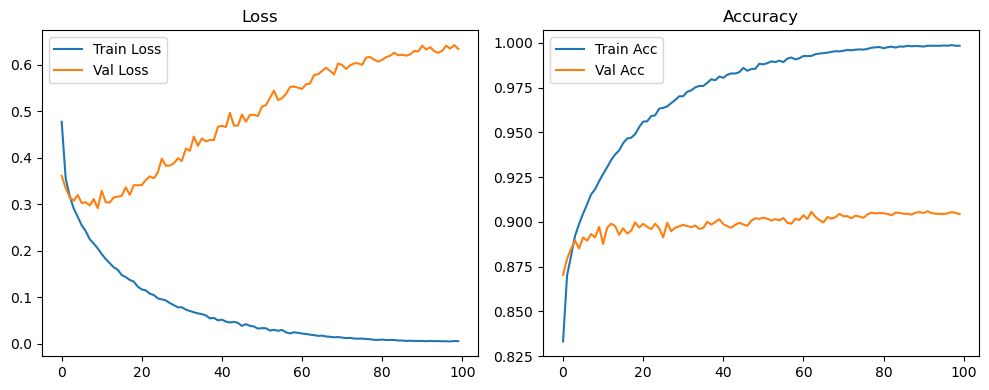

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:00,  2.01it/s]

Evaluation:  67%|██████▋   | 2/3 [00:00<00:00,  2.02it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.70it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.47it/s]

...

| LR: 0.000010 | Train Acc: 0.9956 | Val Acc: 0.9058 |:  99%|█████████▉| 99/100 [04:04<00:02,  2.44s/it]

| LR: 0.000010 | Train Acc: 0.9955 | Val Acc: 0.9072 |:  99%|█████████▉| 99/100 [04:07<00:02,  2.44s/it]

| LR: 0.000010 | Train Acc: 0.9955 | Val Acc: 0.9072 |:  99%|█████████▉| 99/100 [04:07<00:02,  2.44s/it]

| LR: 0.000010 | Train Acc: 0.9955 | Val Acc: 0.9072 |: 100%|██████████| 100/100 [04:07<00:00,  2.46s/it]

| LR: 0.000010 | Train Acc: 0.9955 | Val Acc: 0.9072 |: 100%|██████████| 100/100 [04:07<00:00,  2.47s/it]

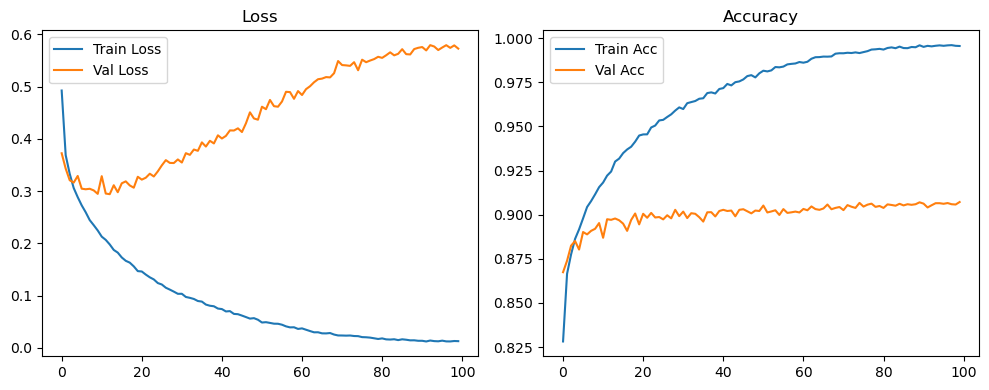

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.92it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.94it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.61it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.38it/s]

...

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9025 |:  99%|█████████▉| 99/100 [04:00<00:02,  2.43s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9023 |:  99%|█████████▉| 99/100 [04:03<00:02,  2.43s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9023 |:  99%|█████████▉| 99/100 [04:03<00:02,  2.43s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9023 |: 100%|██████████| 100/100 [04:03<00:00,  2.38s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9023 |: 100%|██████████| 100/100 [04:03<00:00,  2.43s/it]

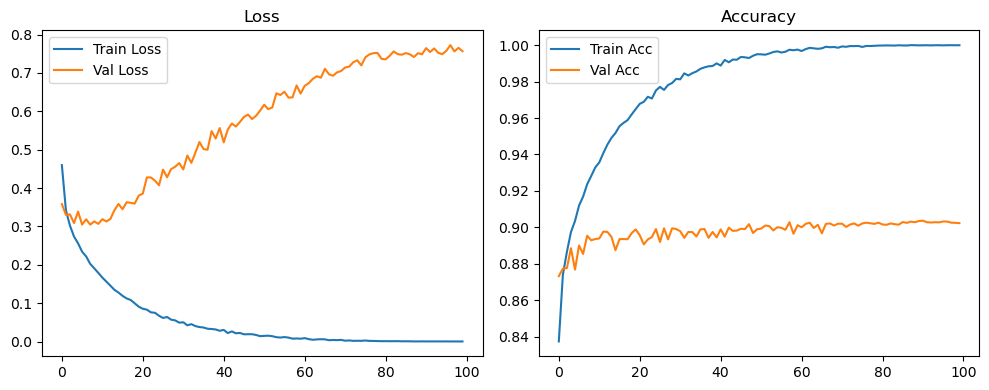

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.51it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.73it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.41it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.14it/s]

...

| LR: 0.000001 | Train Acc: 0.9985 | Val Acc: 0.9026 |:  99%|█████████▉| 99/100 [04:11<00:02,  2.58s/it]

| LR: 0.000001 | Train Acc: 0.9985 | Val Acc: 0.9022 |:  99%|█████████▉| 99/100 [04:14<00:02,  2.58s/it]

| LR: 0.000001 | Train Acc: 0.9985 | Val Acc: 0.9022 |:  99%|█████████▉| 99/100 [04:14<00:02,  2.58s/it]

| LR: 0.000001 | Train Acc: 0.9985 | Val Acc: 0.9022 |: 100%|██████████| 100/100 [04:14<00:00,  2.54s/it]

| LR: 0.000001 | Train Acc: 0.9985 | Val Acc: 0.9022 |: 100%|██████████| 100/100 [04:14<00:00,  2.54s/it]

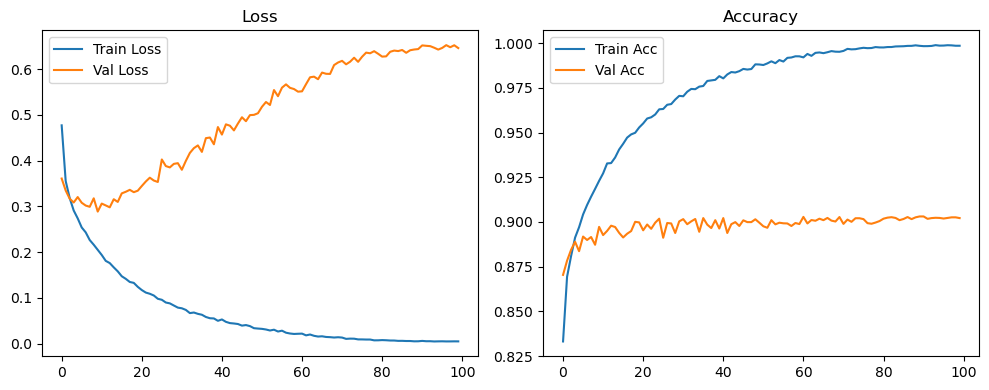

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.87it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  1.92it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.64it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.39it/s]

...

| LR: 0.000001 | Train Acc: 0.9958 | Val Acc: 0.9068 |:  99%|█████████▉| 99/100 [04:10<00:02,  2.61s/it]

| LR: 0.000001 | Train Acc: 0.9955 | Val Acc: 0.9070 |:  99%|█████████▉| 99/100 [04:12<00:02,  2.61s/it]

| LR: 0.000001 | Train Acc: 0.9955 | Val Acc: 0.9070 |:  99%|█████████▉| 99/100 [04:12<00:02,  2.61s/it]

| LR: 0.000001 | Train Acc: 0.9955 | Val Acc: 0.9070 |: 100%|██████████| 100/100 [04:12<00:00,  2.56s/it]

| LR: 0.000001 | Train Acc: 0.9955 | Val Acc: 0.9070 |: 100%|██████████| 100/100 [04:12<00:00,  2.53s/it]

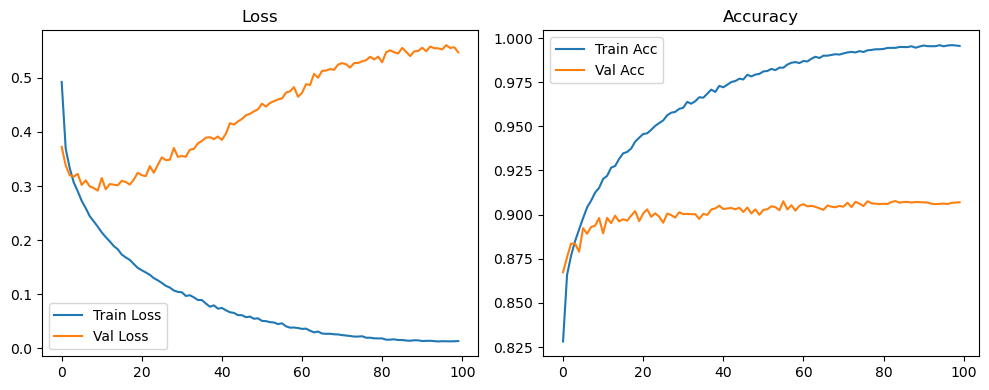

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:00<00:01,  1.95it/s]

Evaluation:  67%|██████▋   | 2/3 [00:01<00:00,  2.00it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.45it/s]

Original Model Final Test Loss: 0.5673 Accuracy: 0.8999


🏆 Best Config: batch64_lr_max_0.0005_min_1e-06_dp0.05 Accuracy: 0.9056


In [15]:
Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)